Train set: (800, 11) (800,)
Test set: (200, 11) (200,)
Train set Accuracy:  0.5475
Test set Accuracy:  0.32


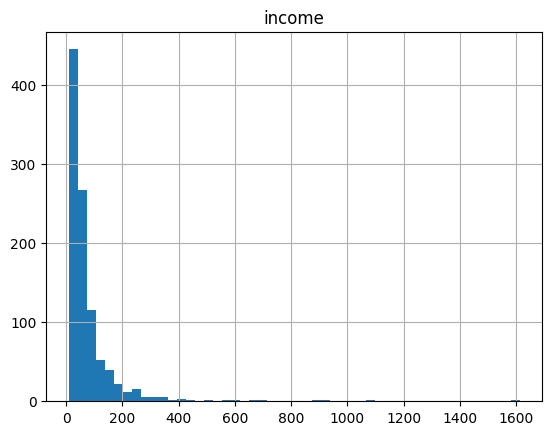

In [3]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
%matplotlib inline

df = pd.read_csv('/home/jupyter/work/data/teleCust1000t.csv')
df['income']=df['income']*np.random.rand()
df.head()

df['custcat'].value_counts()

df.hist(column='income', bins=50)

df.columns

X = df[['region', 'tenure','age', 'marital', 'address', 'income', 'ed', 'employ','retire', 'gender', 'reside']].values  #.astype(float)
X[0:5]

y = df['custcat'].values
y[0:5]

X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))
X[0:5]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

k = 4
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
neigh

yhat = neigh.predict(X_test)
yhat[0:5]

print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat))

Результаты для k=1..9:


,k,Accuracy_train,Accuracy_test,F1_train_weighted,F1_test_weighted
0,1,1.00000,0.300,1.000000,0.299440
1,2,0.61750,0.290,0.578072,0.245477
2,3,0.56875,0.315,0.565826,0.295275
3,4,0.54750,0.320,0.541728,0.311620
4,5,0.53750,0.315,0.531684,0.305136
5,6,0.51625,0.310,0.505787,0.300953
6,7,0.51250,0.335,0.500987,0.332445
7,8,0.49250,0.325,0.481741,0.315497
8,9,0.50250,0.340,0.494302,0.329664



Оптимальное k по F1_test_weighted: 7
Accuracy_test = 0.3350
F1_test_weighted = 0.3324


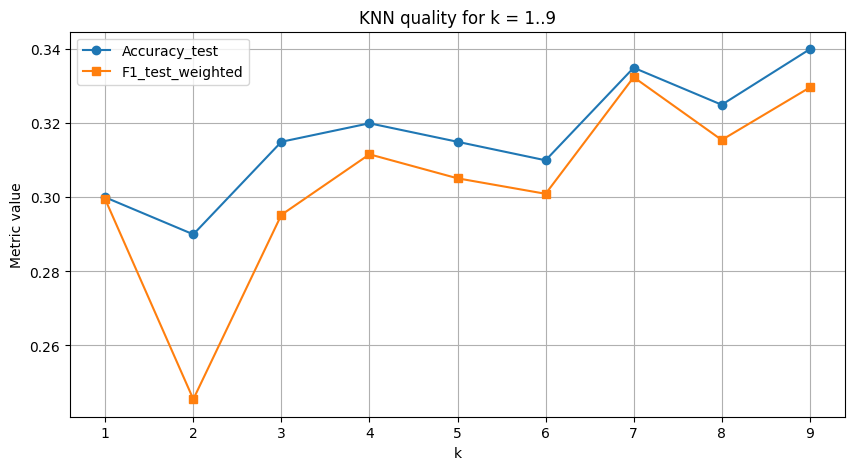

In [6]:
# --- Задание: модели для k = 1..9, метрики Accuracy и F1 ---

from sklearn.metrics import f1_score

results = []

for k in range(1, 10):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    acc_train = metrics.accuracy_score(y_train, y_pred_train)
    acc_test = metrics.accuracy_score(y_test, y_pred_test)

    # Для многоклассовой задачи корректнее использовать weighted
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')

    results.append([k, acc_train, acc_test, f1_train, f1_test])

results_df = pd.DataFrame(
    results,
    columns=['k', 'Accuracy_train', 'Accuracy_test', 'F1_train_weighted', 'F1_test_weighted']
)

print("Результаты для k=1..9:")
display(results_df)

# Выбор оптимального k по F1 на тесте
best_row = results_df.loc[results_df['F1_test_weighted'].idxmax()]
best_k = int(best_row['k'])

print(f"\nОптимальное k по F1_test_weighted: {best_k}")
print(f"Accuracy_test = {best_row['Accuracy_test']:.4f}")
print(f"F1_test_weighted = {best_row['F1_test_weighted']:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(results_df['k'], results_df['Accuracy_test'], marker='o', label='Accuracy_test')
plt.plot(results_df['k'], results_df['F1_test_weighted'], marker='s', label='F1_test_weighted')
plt.xticks(range(1, 10))
plt.xlabel('k')
plt.ylabel('Metric value')
plt.title('KNN quality for k = 1..9')
plt.grid(True)
plt.legend()
plt.show()